# Exploratory Data Analysis — Telco Customer Churn

Goal: understand who churns and why, before building any model.
We're looking for real business drivers, not just correlations —
things like contract type, tenure, and payment method that a
retention team could actually act on.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/raw_telco.csv")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["MonthlyCharges"] * df["tenure"])

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Overall churn rate

Overall churn rate: 26.5%


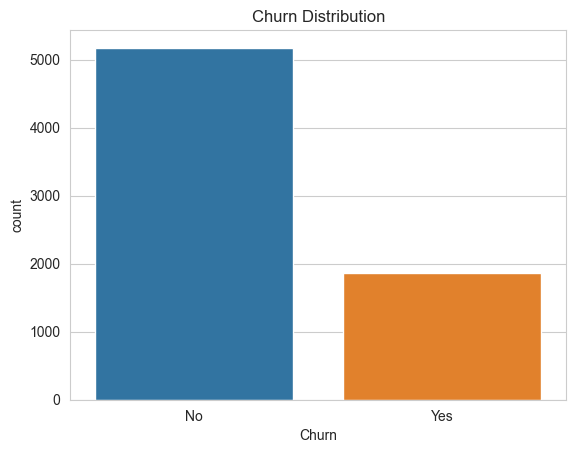

In [2]:
churn_rate = (df["Churn"] == "Yes").mean()
print(f"Overall churn rate: {churn_rate:.1%}")

sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.show()

**Note:** churn is imbalanced (~26-27% typically for this dataset).
This is why we'll use PR-AUC instead of accuracy later in train.py —
a model that just predicts "no churn" for everyone would still score
~73% accuracy while being useless.

## 2. Churn by contract type

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64


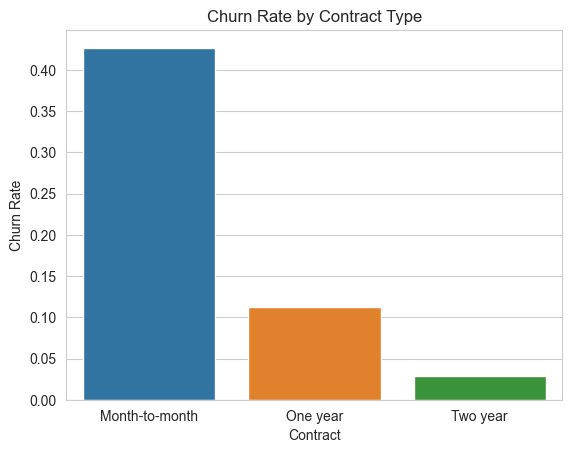

In [3]:
contract_churn = df.groupby("Contract")["Churn"].apply(lambda x: (x == "Yes").mean())
print(contract_churn)

sns.barplot(x=contract_churn.index, y=contract_churn.values)
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Contract Type")
plt.show()

**Expected insight:** month-to-month customers churn far more than
one/two-year contract customers — this is usually the single strongest
signal in this dataset, and it's actionable (incentivize longer contracts).

## 3. Churn by tenure

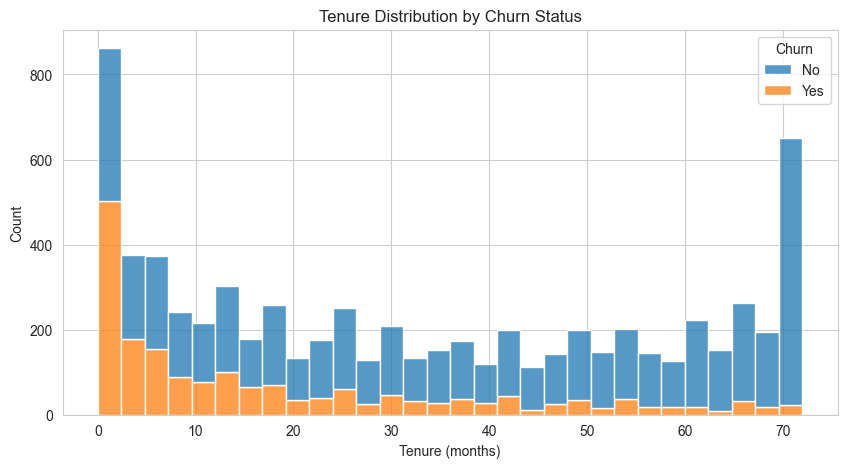

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", bins=30)
plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Tenure (months)")
plt.show()

**Expected insight:** churn is heavily concentrated in the first few
months. This supports an "early lifecycle" intervention strategy —
customers who make it past ~12 months are much stickier.

## 4. Churn by payment method

PaymentMethod
Electronic check             0.452854
Mailed check                 0.191067
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Name: Churn, dtype: float64


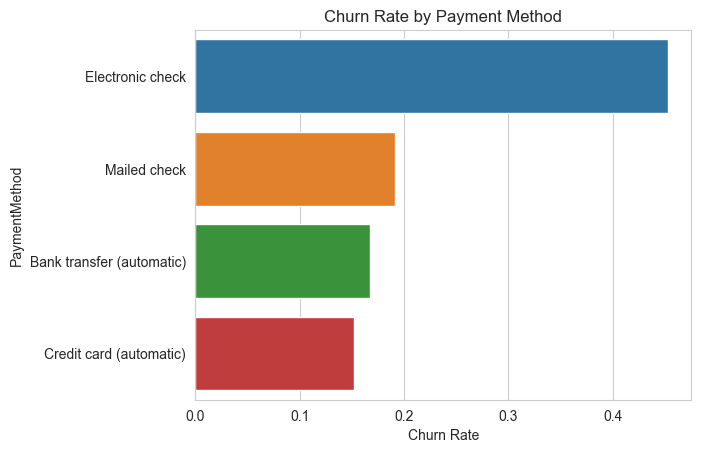

In [5]:
payment_churn = df.groupby("PaymentMethod")["Churn"].apply(lambda x: (x == "Yes").mean()).sort_values(ascending=False)
print(payment_churn)

sns.barplot(x=payment_churn.values, y=payment_churn.index)
plt.xlabel("Churn Rate")
plt.title("Churn Rate by Payment Method")
plt.show()

**Expected insight:** electronic check payers typically churn at
notably higher rates than autopay users (credit card/bank transfer).
This is the basis for the `high_friction_payment` feature in features.py.

## 5. Monthly charges vs churn

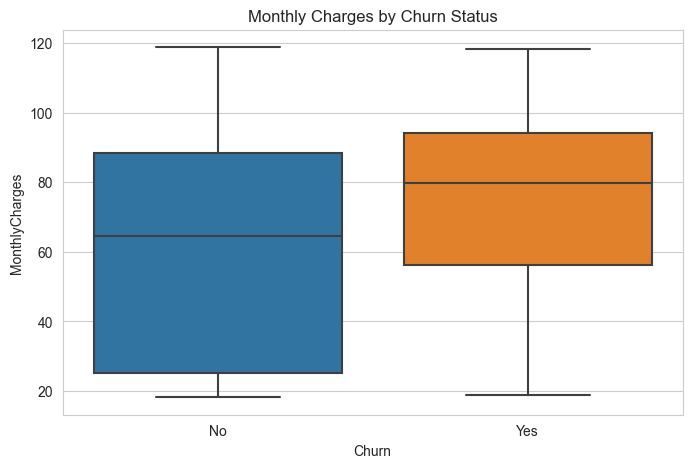

In [6]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn Status")
plt.show()

## 6. Service bundle count vs churn

service_count
0    0.214060
1    0.457557
2    0.358180
3    0.273703
4    0.223005
5    0.124343
6    0.052817
Name: Churn, dtype: float64


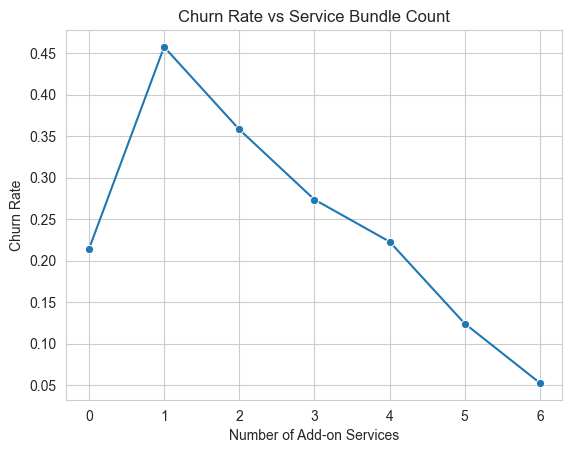

In [7]:
service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                "TechSupport", "StreamingTV", "StreamingMovies"]
df["service_count"] = (df[service_cols] == "Yes").sum(axis=1)

service_churn = df.groupby("service_count")["Churn"].apply(lambda x: (x == "Yes").mean())
print(service_churn)

sns.lineplot(x=service_churn.index, y=service_churn.values, marker="o")
plt.xlabel("Number of Add-on Services")
plt.ylabel("Churn Rate")
plt.title("Churn Rate vs Service Bundle Count")
plt.show()

**Expected insight:** customers with more bundled services tend to
churn less — this supports the `service_count` feature and suggests
bundling could be a retention lever, not just a revenue one.

## Summary of findings

- Churn is imbalanced (~26-27%) — use PR-AUC, not accuracy, for modeling
- Contract type is likely the strongest single driver (month-to-month >> longer contracts)
- Churn risk is highest in the first 12 months of tenure
- Electronic check payers churn more than autopay users
- More bundled services correlates with lower churn

These findings directly informed the feature engineering in `features.py`
(tenure buckets, service count, payment friction flag) and the CLV
discounting logic in `enrich.py` (month-to-month contracts get a
lower projected future value due to higher churn risk).